In [ ]:
import xwrf
import glob
import pickle

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from datetime import datetime
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import numpy as np
from wrf import latlon_coords, ll_to_xy, xy_to_ll
from netCDF4 import Dataset

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Plot hourly mean temperature time series – observed vs. modelled (Default, LCZ, WSF-MB, and Geoscape experiments) – at DCCEEW stations - Figures S3-S4

In [2]:
with open("/g/data/gb02/mf9078/WRF_Results-10-20Jan_xy_wtime_DCCEEW_mean.pkl", "rb") as f:
    wrf_stations = pickle.load(f)

In [ ]:
#load obs data in the desired format
# Read the CSV file
df = pd.read_csv('/g/data/gb02/mf9078/T-DCCEEW.csv')

# Combine Date and Time columns into a single datetime column
#df['Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M')
df['Time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].astype(str), dayfirst=True)

# Drop the original Date and Time columns (optional)
df = df.drop(['Date'], axis=1)

# Reorder columns to put Time first
cols = ['Time'] + [col for col in df.columns if col != 'Time']
df = df[cols]

# Drop the last 24 hours (info on 20 Jan not needed)
df = df.iloc[:-24] #df = df.dropna()
print(f"\nRows after removing NaN values: {len(df)}")

# Display basic information about the dataframe
print("DataFrame Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())
print("\nBasic statistics:")
print(df.describe())

# Check for any missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Display the station columns
station_cols = ['RK', 'RE', 'LL', 'CA', 'ED', 'SS', 'PT', 'CN']
print(f"\nStation columns available: {station_cols}")
print(f"Total number of records: {len(df)}")
print(f"Date range: {df['Time'].min()} to {df['Time'].max()}")


Rows after removing NaN values: 241
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    241 non-null    datetime64[ns]
 1   RK      241 non-null    float64       
 2   RE      241 non-null    float64       
 3   LL      241 non-null    float64       
 4   CA      241 non-null    float64       
 5   ED      241 non-null    float64       
 6   SS      241 non-null    float64       
 7   PT      240 non-null    float64       
 8   CN      241 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 17.1 KB
None

First few rows:
                 Time    RK    RE    LL    CA    ED    SS    PT    CN
0 2017-01-10 00:00:00  22.2  22.9  22.4  22.6  22.9  21.9  22.2  22.0
1 2017-01-10 01:00:00  22.0  22.5  22.3  22.2  22.5  21.8  21.6  21.8
2 2017-01-10 02:00:00  21.9  22.2  22.4  22.2  22.3  21.8  21.6  21

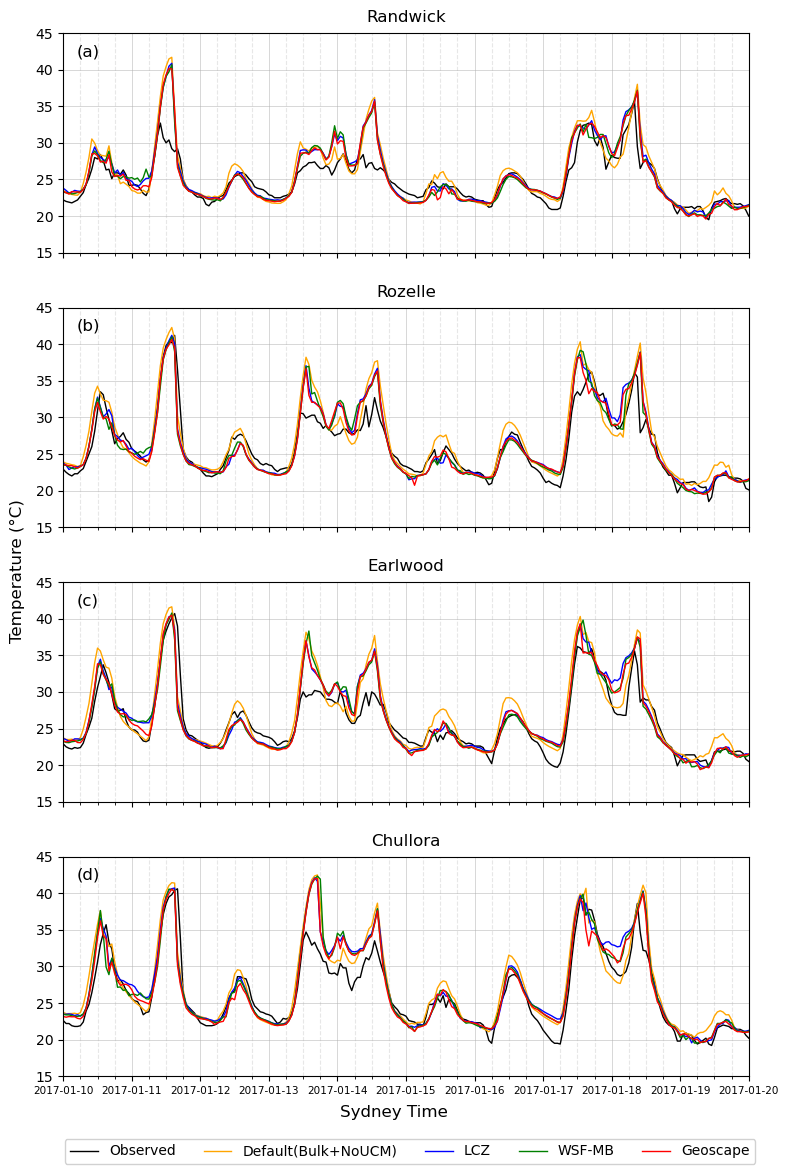

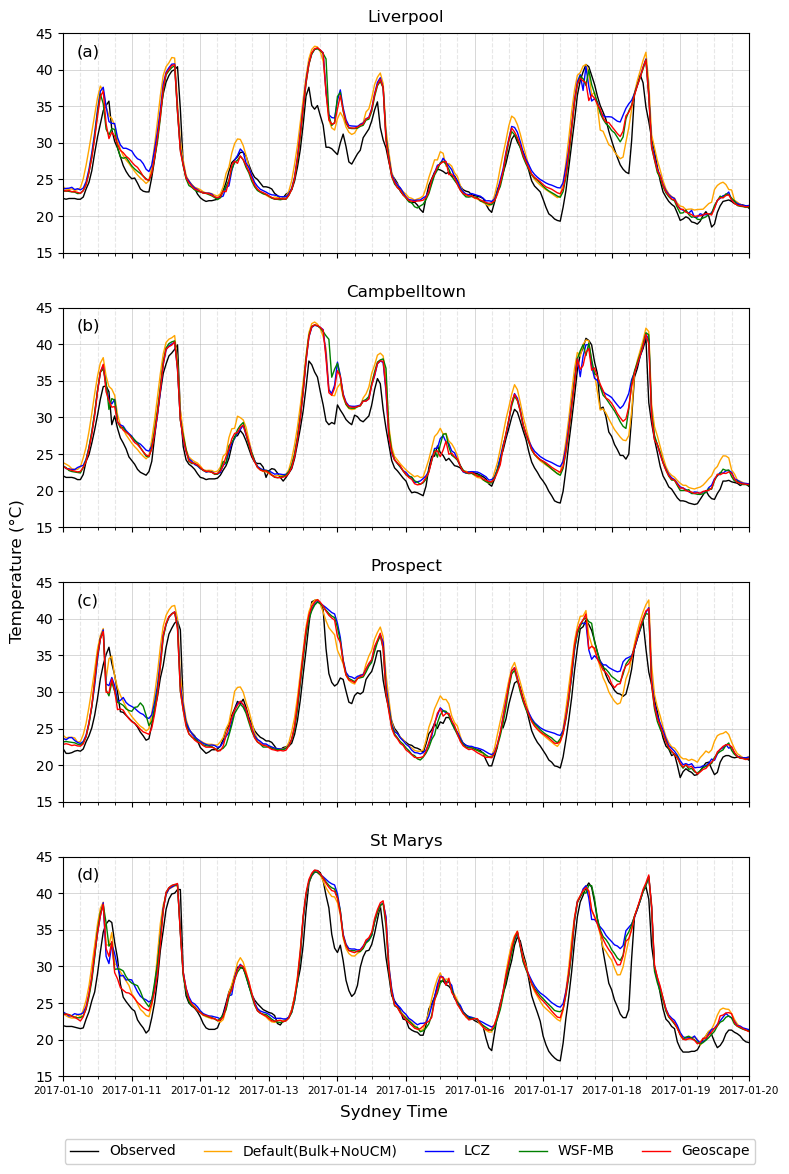

In [ ]:
#plot Temperature time series at each station
# Define station names and colors
stations = {
    'RK': 'Randwick', 'RE': 'Rozelle', 'ED': 'Earlwood',
    'CA': 'Chullora', 'LL': 'Liverpool', 'CN': 'Campbelltown', 
    'PT': 'Prospect', 'SS': 'St Marys'
}

line_colors = {
    'Default(Bulk+NoUCM)': 'orange',
    'LCZ': 'blue',
    'WSF-MB': 'green', 
    'Geoscape': 'red'
}

# Split stations into two groups
station_items = list(stations.items())
first_four = station_items[:4]
second_four = station_items[4:]

# Create first figure with 4x1 subplots
fig1, axes1 = plt.subplots(4, 1, figsize=(8, 12), sharex=True, sharey=True)

# Plot data for first four stations
for idx, (station_code, station_name) in enumerate(first_four):
    ax = axes1[idx]
    
    # Plot observed data (black line)
    ax.plot(df['Time'], df[station_code], color='black', 
            linewidth=1, label='Observed')
    
    # Plot modelled data for each scenario
    for scenario, color in line_colors.items():
        ax.plot(wrf_stations['time'], wrf_stations[scenario][station_code], 
                color=color, linewidth=1, label=scenario)
    
    # Set title
    ax.set_title(station_name, #2m Air Temperature Time Series (Observed vs. Modelled) - 
                 fontsize=12, pad=8)

    # Add subplot label (a), (b), (c), (d)
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.02, 0.95, subplot_labels[idx], transform=ax.transAxes,
            fontsize=12, va='top', ha='left', #fontweight='bold',
            )
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    ax.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
    ax.grid(True, which='major', linestyle='-', alpha=0.7)   # daily
    
    # Format x-axis for bottom subplot only
    if idx == 3:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', which='major', labelsize=7.5)#ax.tick_params(axis='x', rotation=45)

# Add horizontal legend at the bottom of first figure
handles, labels = axes1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='lower center', ncol=5, fontsize=10, 
            framealpha=0.9, bbox_to_anchor=(0.52, 0))

# Set common labels for first figure
fig1.text(0.5, 0.045, 'Sydney Time', ha='center', fontsize=12)
fig1.text(0.02, 0.5, 'Temperature (°C)', va='center', rotation='vertical', 
          fontsize=12)

# Adjust layout for first figure
axes1[0].set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))
axes1[0].set_ylim(15, 45)
plt.tight_layout(rect=[0.03, 0.05, 1, 0.98])
plt.savefig("/g/data/gb02/mf9078/plots/Temperature_Timeseries_4DCCEEWstations1.png", dpi=300)
plt.subplots_adjust(hspace=0.25)

# Create second figure with 4x1 subplots
fig2, axes2 = plt.subplots(4, 1, figsize=(8, 12), sharex=True, sharey=True)

# Plot data for second four stations
for idx, (station_code, station_name) in enumerate(second_four):
    ax = axes2[idx]
    
    # Plot observed data (black line)
    ax.plot(df['Time'], df[station_code], color='black', 
            linewidth=1, label='Observed')
    
    # Plot modelled data for each scenario
    for scenario, color in line_colors.items():
        ax.plot(wrf_stations['time'], wrf_stations[scenario][station_code], 
                color=color, linewidth=1, label=scenario)
    
    # Set title
    ax.set_title(f'{station_name}', #2m Air Temperature Time Series (Observed vs. Modelled) - 
                 fontsize=12, pad=8)

    # Add subplot label (a), (b), (c), (d)
    subplot_labels = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.02, 0.95, subplot_labels[idx], transform=ax.transAxes,
            fontsize=12, va='top', ha='left', #fontweight='bold',
            )
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    ax.grid(True, which='minor', linestyle='--', alpha=0.3)  # 6-hourly
    ax.grid(True, which='major', linestyle='-', alpha=0.7)   # daily
    
    # Format x-axis for bottom subplot only
    if idx == 3:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.tick_params(axis='x', which='major', labelsize=7.5) #(axis='x', rotation=45)

# Add horizontal legend at the bottom of second figure
handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower center', ncol=5, fontsize=10, 
            framealpha=0.9, bbox_to_anchor=(0.52, 0))

# Set common labels for second figure
fig2.text(0.5, 0.045, 'Sydney Time', ha='center', fontsize=12)
fig2.text(0.02, 0.5, 'Temperature (°C)', va='center', rotation='vertical', 
          fontsize=12)

# Adjust layout for second figure
axes2[0].set_xlim(pd.to_datetime("2017-01-10"), pd.to_datetime("2017-01-20"))
axes2[0].set_ylim(15, 45)
plt.tight_layout(rect=[0.03, 0.05, 1, 0.98])
plt.savefig("/g/data/gb02/mf9078/plots/Temperature_Timeseries_4DCCEEWstations2.png", dpi=300)
plt.subplots_adjust(hspace=0.25)

plt.show()